# Project 3

group:
- Ole Lie-Bjelland
- Anniken Marie Lingstad
- Emil Ingar Hals

We did NOT use any AI for this project.

## Topic 1

### Task 0

Our coordnate box will use angstrom units. To ensure that all the points in the dna molecule fit in the box we found the lowest and highest of each x,y,z value in the dna_coords.txt file. The box is then expanded by 5 angstrom in every direction to ensure that the atomic radius of each point remains inside the simulation box

In [34]:
from main import gen_simulation_box

simulation_box = gen_simulation_box(10, 10, 10)
simulation_box_volume = simulation_box.volume()

print(f"Simulation box: {simulation_box}")
print(f"Simulation box volume: {simulation_box_volume}")

Simulation box: 
min x: 0
max x: 10
min y: 0
max y: 10
min z: 0
max z: 10

Simulation box volume: 1000


### Task 1

In [35]:
from main import gen_random_points

point_count = 3
points = gen_random_points(simulation_box, point_count)
print(f"Generated {len(points)} random points:")
for p in points:
    print(p)

Generated 3 random points:
x: 6.185068051245252
y: 0.7209143660523387
z: 5.45724621335289

x: 6.013297306526175
y: 8.80828780821118
z: 4.638865592964375

x: 7.592996236878953
y: 9.88956414569823
z: 1.908518881688075



### Task 2

In [36]:
from main import gen_spheres

spheres = gen_spheres(simulation_box, 1)
for s in spheres:
    print(s)

Sphere radius: 1.214371475216541
Sphere location:
x: 7.351287562845158
y: 5.888435618247371
z: 8.508782167214086



### Task 3

In [37]:
from main import point_in_spheres

rand_point = gen_random_points(simulation_box, 1)[0]
print(f"Point: \n{rand_point}")

assert point_in_spheres(spheres, spheres[0].point), "point_in_spheres function not working"   # This should always be true

if point_in_spheres(spheres, rand_point):
    print("The point is in the sphere")
else:
    print("The point is not in the sphere")


Point: 
x: 5.4733603547547025
y: 5.820371325441033
z: 2.7431004863165356

The point is not in the sphere


### Task 4

We can check the montecarlo simulation result by comparing it to the volume of a sphere given by the formula: $V = \frac{4}{3} \pi r^3$


sphere radius is: 1.676423421093817
The fraction of points in the sphere is 0.019843333333333334
The volume of the simulation box is: 1000
Estimated volume of sphere: 19.843333333333334
Analytical volume of sphere: 19.73511985685524


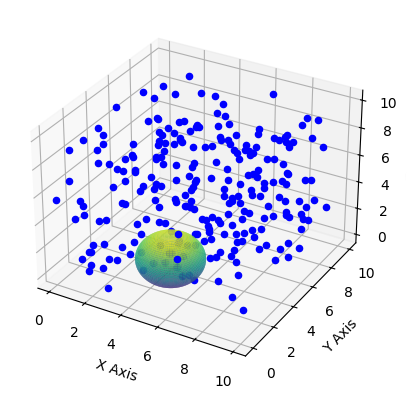

In [38]:
num_of_points = 300000
sphere = gen_spheres(simulation_box, 1)
random_points = gen_random_points(simulation_box, num_of_points)

print(f"sphere radius is: {sphere[0].rad}")

points_in_sphere = 0
for point in random_points:
    if point_in_spheres(sphere, point):
        points_in_sphere += 1

estimated_volume = simulation_box.volume() * (points_in_sphere/num_of_points)

print(f"The fraction of points in the sphere is {points_in_sphere/num_of_points}")
print(f"The volume of the simulation box is: {simulation_box.volume()}")
print(f"Estimated volume of sphere: {estimated_volume}")
print(f"Analytical volume of sphere: {sphere[0].volume()}")

# Plotting
from main import plot_points_and_spheres
plot_points_and_spheres(sphere, random_points[:250])   # Only plotting 250 points because plotting all of them is very slow


### Task 5

$$
V = \frac{4}{3} \pi r^3 \to \pi = \frac{3V}{4 \cdot r^3}
$$

In [39]:
estimated_pi = (estimated_volume*3)/(4*sphere[0].rad**3)
print(f"Estimated pi: {estimated_pi}")

Estimated pi: 3.1588189316762114


### Task 6

In [40]:
spheres = gen_spheres(simulation_box, 10)

# Show the first 3 of the 10 new spheres
for s in spheres[:3]:
    print(s)

Sphere radius: 1.3447965248894866
Sphere location:
x: 4.482504679283757
y: 3.960988625469953
z: 8.633971670065272

Sphere radius: 1.028378236506348
Sphere location:
x: 3.935334957011084
y: 7.761557942046858
z: 4.646266220465845

Sphere radius: 1.958673109153923
Sphere location:
x: 6.879937887106815
y: 3.4195979025227894
z: 7.259266940054365



### Task 7

We can verify the results of the simulation in the same way as in task 4. As we know the radius of all the spheres we can calculate their total volume analytically.

Total volume of simulation box: 1000
The fraction of points in the sphere is 0.13285333333333332
The total volume of the generated spheres is: 132.58
The estimated volume is 132.85333333333332


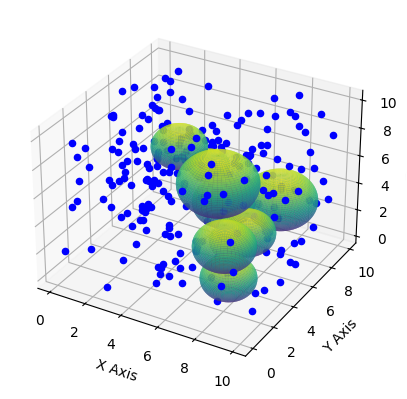

In [41]:
num_of_points = 300000
random_points = gen_random_points(simulation_box, num_of_points)

# Calculate the analytical volume
total_volume = 0
for s in spheres:
    total_volume += s.volume()

points_in_spheres = 0
for point in random_points:
    points_in_spheres += point_in_spheres(spheres, point)

fraction = points_in_spheres/num_of_points
estimated_volume = simulation_box.volume() * fraction
print(f"Total volume of simulation box: {simulation_box.volume()}")
print(f"The fraction of points in the sphere is {fraction}")
print(f"The total volume of the generated spheres is: {round(total_volume, 2)}")
print(f"The estimated volume is {estimated_volume}")

# Plotting
plot_points_and_spheres(spheres, random_points[:250])

### Task 8

In [42]:
from main import get_atoms
atoms = get_atoms()
for a in atoms[:3]:
    print(a)


Atomic symbol: H
Atomic radius: 1.2 angstrom
Position: 
x: -48.18074
y: 1.74518
z: -1.22092



Atomic symbol: O
Atomic radius: 1.52 angstrom
Position: 
x: -48.07374
y: 1.26418
z: -0.40592



Atomic symbol: P
Atomic radius: 1.8 angstrom
Position: 
x: -46.63374
y: 1.27818
z: -0.00492




### Task 9

In [43]:
from main import get_dna_box
dna_box = get_dna_box(atoms)
print("Simulation box for DNA:")
print(dna_box)
print(f"Volume of DNA box: {dna_box.volume()}")

Simulation box for DNA:

min x: -54
max x: -25
min y: -23
max y: 8
min z: -15
max z: 15

Volume of DNA box: 26970


### Task 10

In order to find the analytical volume of the DNA we can use the normal formula for the volume of a sphere as we already know the atomic radius of each atom.

In [44]:
random_point_count = 100000
random_points = gen_random_points(dna_box, random_point_count)

# Check how many of the random points are in the dna
points_in_dna = 0
for p in random_points:
    points_in_dna += point_in_spheres(atoms, p)

fraction = points_in_dna/random_point_count
estimated_dna_volume = dna_box.volume()*fraction

print(f"Volume of simulation box: {dna_box.volume()}")
print(f"Fraction of points in dna: {fraction}")
print(f"Estimated dna volume: {estimated_dna_volume} angstrom^3")


# Analytical approach
import math
analytical_dna_volume = 0
for atom in atoms:
    analytical_dna_volume += math.pi * (4/3) * atom.rad**3

print(f"analytical dna volume: {analytical_dna_volume} angstrom^3")


Volume of simulation box: 26970
Fraction of points in dna: 0.1354
Estimated dna volume: 3651.738 angstrom^3
analytical dna volume: 3672.2768725392457 angstrom^3


## Topic 2

### Task 1

A simple random walk function without numpy to generate a set of walkers in 3d, starting from different random points. Imported from random_walk.py

Walker 1 start: -76.4359531025476, 49.19660973146355, 63.91284852211078
Walker 2 start: -26.06760829528578, 72.22044676396234, -24.11225254110218
Walker 3 start: 35.935425200004204, 1.615934485130552, 94.77117163741738
Walker 4 start: -50.85829691620092, 14.841125333590327, -16.154892042302933
Walker 5 start: 24.129000439354627, 40.98819655846137, -56.26536598094236


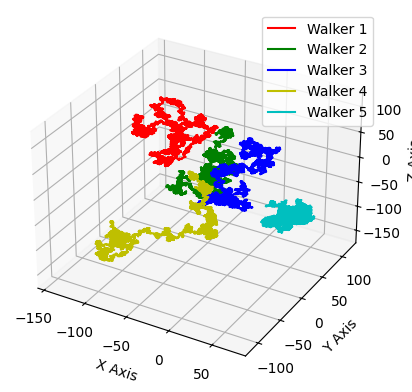

In [45]:
from random_walk import gen_walkers
import matplotlib.pyplot as plt

ITERATIONS = 10000
WALKER_COUNT = 5

walkers = gen_walkers(ITERATIONS, WALKER_COUNT)

# Plotting the random walk
# Source for plot code:
# https://stackoverflow.com/questions/11541123/how-can-i-make-a-3d-line-plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'y', 'c', 'm']

for i, w in enumerate(walkers):
    x_vals = [p[0] for p in w.past_positions]
    y_vals = [p[1] for p in w.past_positions]
    z_vals = [p[2] for p in w.past_positions]

    ax.plot(x_vals, y_vals, z_vals, color=colors[i % len(colors)], label=f'Walker {i+1}')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

plt.legend()
plt.show()

### Task 3

A strategy for calculating the accessible volume of the DNA is to use our function to initiate several walkers at random points in the box with the DNA. As the walkers move through the box, the coordinates will be checked and counted towards the DNA volume if they are within the DNA coordinates. We can then divide the number of walker positions inside the DNA by the total number of walker positions, and get the fraction of the box that the DNA occupies. Multiplying the fraction with the total box volume gives an estimate of the DNA volume, which we can subtract from the total box volume, giving us an estimate of the accessible volume.

### Task 4

To verify that this strategy gives meaningful results, we can test it in a box with known total volume and an object of known volume, for example a sphere, then subtract the total box volume with the sphere volume. We can then compare this calculated volume with the estimate volume from the walkers to see if it is within meaningful range. For a simulation closer to DNA behaviour, we will be testing with several spheres.

In [ ]:
# Testing the accessible volume estimation
import numpy
from accessible_volume import gen_simulation_box, gen_walkers, gen_spheres, point_in_spheres

WALKER_COUNT = 5
STEPS = 10000

simulation_box = gen_simulation_box(10, 10, 10)

w = gen_walkers(STEPS, WALKER_COUNT, simulation_box)

spheres = gen_spheres(simulation_box, 10)

POINTS_IN_SPHERES = 0

for walkers in w:
    for past_position in walkers.past_positions:
        POINTS_IN_SPHERES += point_in_spheres(spheres, past_position)

TOTAL_POINTS = WALKER_COUNT * STEPS
FRACTION = POINTS_IN_SPHERES / TOTAL_POINTS
box_volume = simulation_box.volume()
sphere_volume_estimate = FRACTION * box_volume
print(f"Estimated volume of spheres: {sphere_volume_estimate}")

ACTUAL_SPHERE_VOLUME = 0
for sphere in spheres:
    ACTUAL_SPHERE_VOLUME += sphere.volume()

print(f"Actual volume of spheres: {ACTUAL_SPHERE_VOLUME}")
box_volume = simulation_box.volume()
print(f"Box volume: {box_volume}")
accessible_volume = box_volume - sphere_volume_estimate
print("Estimated accessible volume: "
        + f"(box volume - estimated volume of spheres) = {accessible_volume}")

# Source code for 3d subplots:
# https://matplotlib.org/stable/gallery/mplot3d/subplot3d.html
fig1 = plt.figure()
ax = fig1.add_subplot(111, projection='3d')
ax.set_title('Simulation of the spheres (no walkers)')

# Taken from plot_points_and_spheres function in main.py
for sph in spheres:
    theta = numpy.linspace(0, 2 * numpy.pi, 100)
    phi = numpy.linspace(0, numpy.pi, 50)
    theta, phi = numpy.meshgrid(theta, phi)
    x_sph = sph.rad * numpy.sin(phi) * numpy.cos(theta) + sph.point.x
    y_sph = sph.rad * numpy.sin(phi) * numpy.sin(theta) + sph.point.y
    z_sph = sph.rad * numpy.cos(phi) + sph.point.z
    ax.plot_surface(x_sph, y_sph, z_sph, cmap='viridis', alpha=0.8)

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

colors = ['r', 'g', 'b', 'y', 'c', 'm']

fig2 = plt.figure()
ax = fig2.add_subplot(111, projection='3d')
ax.set_title('Walker paths')

for i, w in enumerate(w):
    x_vals = [p.x for p in w.past_positions]
    y_vals = [p.y for p in w.past_positions]
    z_vals = [p.z for p in w.past_positions]

    ax.plot(x_vals, y_vals, z_vals, color=colors[i % len(colors)], label=f'Walker {i+1}')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

plt.legend()
plt.show()

Estimated volume of spheres: 120.42
Actual volume of spheres: 120.004020474795
Box volume: 1000
Estimated accessible volume: (box volume - estimated volume of spheres) = 879.58


NameError: name 'plt' is not defined

### Task 5

While working on the montecarlo simulation we discovered that the simulation has a relatively large standard deviation, but it also had a consistently accurate average estimate if running multiple simulations. After some experimentation we decided that taking the average of 5 simulations is a nice spot between speed and accuracy. 

In [2]:
from accessible_volume import accessible_volume_simulation

WALKER_COUNT = 250
STEPS = 100
results = []

# DNA simulation
atoms = get_atoms()
dna_box = get_dna_box(atoms)
for i in range(5):
    result, _ = accessible_volume_simulation(WALKER_COUNT, STEPS, dna_box, atoms)
    results.append(result)
average = sum(results) / len(results)

print("-"*40 + "\nDNA Simulation Result")
print(f"Average result over 5 runs: {average}")

NameError: name 'get_atoms' is not defined